<a href="https://colab.research.google.com/github/basedmonke05/customer-churn-prediction/blob/main/Customer_Churn_Predictions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Predictions

In [ ]:
# Essential imports for data science and machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# PyTorch for deep learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                           roc_auc_score, roc_curve, precision_recall_curve,
                           f1_score, precision_score, recall_score)
from sklearn.utils.class_weight import compute_class_weight

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Configure visualization
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
sns.set_palette("husl")

# Check device availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Environment Setup:")
print(f"   Device: {device}")
print(f"   PyTorch Version: {torch.__version__}")
print(f"   Pandas Version: {pd.__version__}")
print(f"   NumPy Version: {np.__version__}")

if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

print("\n✅ All libraries imported successfully!")
print("📊 Ready to begin customer churn analysis...")

🚀 Environment Setup:
   Device: cuda
   PyTorch Version: 2.9.0+cu126
   Pandas Version: 2.2.2
   NumPy Version: 2.0.2
   GPU: Tesla T4
   GPU Memory: 14.7 GB

✅ All libraries imported successfully!
📊 Ready to begin customer churn analysis...


## Data Loading and First Look

In [ ]:
!pip install gdown
!gdown https://drive.google.com/uc?id=1xM2bFllWdNVVge0awuTKXvY_grM78vXD

Downloading...
From: https://drive.google.com/uc?id=1xM2bFllWdNVVge0awuTKXvY_grM78vXD
To: /content/Telco-Customer-Churn.csv
100% 970k/970k [00:00<00:00, 109MB/s]


In [ ]:
df = pd.read_csv('Telco-Customer-Churn.csv')

In [ ]:
print(f'samples : {df.shape[0]} , columns : {df.shape[1]} \n')
info_df = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes,
    'Non-Null Count': df.count(),
    'Null Count': df.isnull().sum(),
    'Null %': (df.isnull().sum() / len(df) * 100).round(2),
    'Unique Values': df.nunique()
})

print(info_df.to_string(index=False))

samples : 7043 , columns : 21 

          Column Data Type  Non-Null Count  Null Count  Null %  Unique Values
      customerID    object            7043           0     0.0           7043
          gender    object            7043           0     0.0              2
   SeniorCitizen     int64            7043           0     0.0              2
         Partner    object            7043           0     0.0              2
      Dependents    object            7043           0     0.0              2
          tenure     int64            7043           0     0.0             73
    PhoneService    object            7043           0     0.0              2
   MultipleLines    object            7043           0     0.0              3
 InternetService    object            7043           0     0.0              3
  OnlineSecurity    object            7043           0     0.0              3
    OnlineBackup    object            7043           0     0.0              3
DeviceProtection    object      

In [ ]:
churn_counts = df['Churn'].value_counts()
churn_percentages = df['Churn'].value_counts(normalize=True) * 100

for category, count in churn_counts.items():
    percentage = churn_percentages[category]
    print(f"{category}: {count:,} customers ({percentage:.1f}%)")


majority = churn_counts.max()
minority = churn_counts.min()

imbalance_ratio = majority/minority

print(f"\nClass imbalance ratio : {imbalance_ratio}")

if imbalance_ratio > 3:
    print("\nSignificant class imbalance detected - will need special handling")
else:
    print("\n=> Mild class imbalance - standard techniques should work")

No: 5,174 customers (73.5%)
Yes: 1,869 customers (26.5%)

Class imbalance ratio : 2.7683253076511503

=> Mild class imbalance - standard techniques should work


## Data Cleaning and Quality Assessment

In [ ]:
# Deep dive into data quality issues
print("🧹 Data Cleaning and Quality Assessment")
print("=" * 50)

# Create a copy for cleaning
df_cleaned = df.copy()
original_shape = df_cleaned.shape

print(f"📊 Starting with {original_shape[0]:,} rows and {original_shape[1]} columns")

# 1. Check for duplicate customer IDs
print(f"\n1️⃣ Checking for duplicate customers...")
duplicate_customers = df_cleaned['customerID'].duplicated().sum()
print(f"   Duplicate customerIDs: {duplicate_customers}")

if duplicate_customers > 0:
    print("   🔧 Removing duplicate customer records...")
    df_cleaned = df_cleaned.drop_duplicates(subset=['customerID'])
    print(f"   ✅ Removed {duplicate_customers} duplicate records")

# 2. Handle TotalCharges data type issue (common in this dataset)
print(f"\n2️⃣ Fixing TotalCharges data type...")
print(f"   Current TotalCharges type: {df_cleaned['TotalCharges'].dtype}")

# Check for non-numeric values in TotalCharges
if df_cleaned['TotalCharges'].dtype == 'object':
    non_numeric_total = df_cleaned['TotalCharges'].apply(lambda x: not str(x).replace('.', '').replace(' ', '').isdigit())
    non_numeric_count = non_numeric_total.sum()
    print(f"   Non-numeric TotalCharges values: {non_numeric_count}")

    if non_numeric_count > 0:
        print("   🔧 Converting TotalCharges to numeric...")
        # Convert to numeric, invalid values become NaN
        df_cleaned['TotalCharges'] = pd.to_numeric(df_cleaned['TotalCharges'], errors='coerce')
        print(f"   ✅ TotalCharges converted to numeric type")

# 3. Handle missing values
print(f"\n3️⃣ Handling missing values...")
missing_values = df_cleaned.isnull().sum()
missing_percent = (missing_values / len(df_cleaned) * 100).round(2)

missing_summary = pd.DataFrame({
    'Column': missing_values.index,
    'Missing Count': missing_values.values,
    'Missing %': missing_percent.values
})
missing_summary = missing_summary[missing_summary['Missing Count'] > 0]

if len(missing_summary) > 0:
    print("   Missing values found:")
    print(missing_summary.to_string(index=False))

    # Handle TotalCharges missing values (likely new customers with 0 tenure)
    if 'TotalCharges' in missing_summary['Column'].values:
        total_charges_missing = df_cleaned['TotalCharges'].isnull().sum()
        print(f"\n   🔧 Handling {total_charges_missing} missing TotalCharges values...")

        # Check if missing TotalCharges correspond to low tenure customers
        missing_tenure = df_cleaned[df_cleaned['TotalCharges'].isnull()]['tenure'].describe()
        print(f"   Tenure stats for missing TotalCharges customers:")
        print(f"   Mean tenure: {missing_tenure['mean']:.1f} months")

        if missing_tenure['mean'] < 3:  # Very new customers
            print("   💡 Missing TotalCharges likely represent new customers")
            print("   🔧 Filling missing TotalCharges with MonthlyCharges (first month)")
            df_cleaned['TotalCharges'] = df_cleaned['TotalCharges'].fillna(df_cleaned['MonthlyCharges'])
        else:
            print("   🔧 Filling missing TotalCharges with median value")
            df_cleaned['TotalCharges'] = df_cleaned['TotalCharges'].fillna(df_cleaned['TotalCharges'].median())

        print("   ✅ TotalCharges missing values handled")
else:
    print("   ✅ No missing values found")

# 4. Check for outliers in numerical columns
print(f"\n4️⃣ Checking for outliers...")
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

outlier_summary = []
for col in numerical_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_cleaned[(df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_percent = (outlier_count / len(df_cleaned)) * 100

    outlier_summary.append({
        'Column': col,
        'Outlier Count': outlier_count,
        'Outlier %': f"{outlier_percent:.1f}%",
        'Lower Bound': f"{lower_bound:.2f}",
        'Upper Bound': f"{upper_bound:.2f}"
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

# 5. Validate business logic
print(f"\n5️⃣ Validating business logic...")

# Check if TotalCharges makes sense with tenure and MonthlyCharges
df_cleaned['ExpectedTotalCharges'] = df_cleaned['tenure'] * df_cleaned['MonthlyCharges']
df_cleaned['ChargesDifference'] = abs(df_cleaned['TotalCharges'] - df_cleaned['ExpectedTotalCharges'])

# Allow for some variance (promotions, price changes, etc.)
threshold = df_cleaned['MonthlyCharges'] * 3  # 3 months worth of charges difference
suspicious_charges = df_cleaned['ChargesDifference'] > threshold
suspicious_count = suspicious_charges.sum()

print(f"   Customers with suspicious charge calculations: {suspicious_count} ({suspicious_count/len(df_cleaned)*100:.1f}%)")

if suspicious_count > 0 and suspicious_count < len(df_cleaned) * 0.1:  # Less than 10%
    print("   💡 Small number of suspicious charges - likely due to promotions/discounts")
    print("   ✅ Keeping all records (realistic business scenario)")
elif suspicious_count > len(df_cleaned) * 0.1:
    print("   ⚠️ High number of suspicious charges - data quality issue")

# Remove the temporary calculation columns
df_cleaned = df_cleaned.drop(['ExpectedTotalCharges', 'ChargesDifference'], axis=1)

# 6. Standardize categorical values
print(f"\n6️⃣ Standardizing categorical values...")
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns.tolist()
if 'customerID' in categorical_cols:
    categorical_cols.remove('customerID')

for col in categorical_cols:
    unique_values = df_cleaned[col].unique()
    print(f"   {col}: {unique_values}")

    # Check for common inconsistencies
    if any('no phone service' in str(val).lower() for val in unique_values):
        print(f"   🔧 Standardizing 'No phone service' values in {col}")
        df_cleaned[col] = df_cleaned[col].replace('No phone service', 'No')

    if any('no internet service' in str(val).lower() for val in unique_values):
        print(f"   🔧 Standardizing 'No internet service' values in {col}")
        df_cleaned[col] = df_cleaned[col].replace('No internet service', 'No')

print(f"\n✅ Data cleaning completed!")
print(f"📊 Final dataset: {df_cleaned.shape[0]:,} rows × {df_cleaned.shape[1]} columns")

# Summary of changes
rows_removed = original_shape[0] - df_cleaned.shape[0]
if rows_removed > 0:
    print(f"🗑️ Removed {rows_removed} rows ({rows_removed/original_shape[0]*100:.1f}%)")

print(f"🎯 Dataset ready for exploratory data analysis!")

# Quick validation
print(f"\n🔍 Post-cleaning validation:")
print(f"   Missing values: {df_cleaned.isnull().sum().sum()}")
print(f"   Duplicate customers: {df_cleaned['customerID'].duplicated().sum()}")
print(f"   Data types: {df_cleaned.dtypes.value_counts().to_dict()}")

# Save cleaned data reference
print(f"\n💾 Cleaned dataset ready for analysis")
print(f"   Shape: {df_cleaned.shape}")
print(f"   Memory usage: {df_cleaned.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

🧹 Data Cleaning and Quality Assessment
📊 Starting with 7,043 rows and 21 columns

1️⃣ Checking for duplicate customers...
   Duplicate customerIDs: 0

2️⃣ Fixing TotalCharges data type...
   Current TotalCharges type: object
   Non-numeric TotalCharges values: 11
   🔧 Converting TotalCharges to numeric...
   ✅ TotalCharges converted to numeric type

3️⃣ Handling missing values...
   Missing values found:
      Column  Missing Count  Missing %
TotalCharges             11       0.16

   🔧 Handling 11 missing TotalCharges values...
   Tenure stats for missing TotalCharges customers:
   Mean tenure: 0.0 months
   💡 Missing TotalCharges likely represent new customers
   🔧 Filling missing TotalCharges with MonthlyCharges (first month)
   ✅ TotalCharges missing values handled

4️⃣ Checking for outliers...
        Column  Outlier Count Outlier % Lower Bound Upper Bound
        tenure              0      0.0%      -60.00      124.00
MonthlyCharges              0      0.0%      -46.02      171.3

## EDA

Overall Churn Rate: 26.5%
Business Impact: 1869 customers churned
2️⃣ Analyzing Services vs Churn...
3️⃣ Analyzing Numerical Variables vs Churn...
4️⃣ Analyzing Service Bundles...


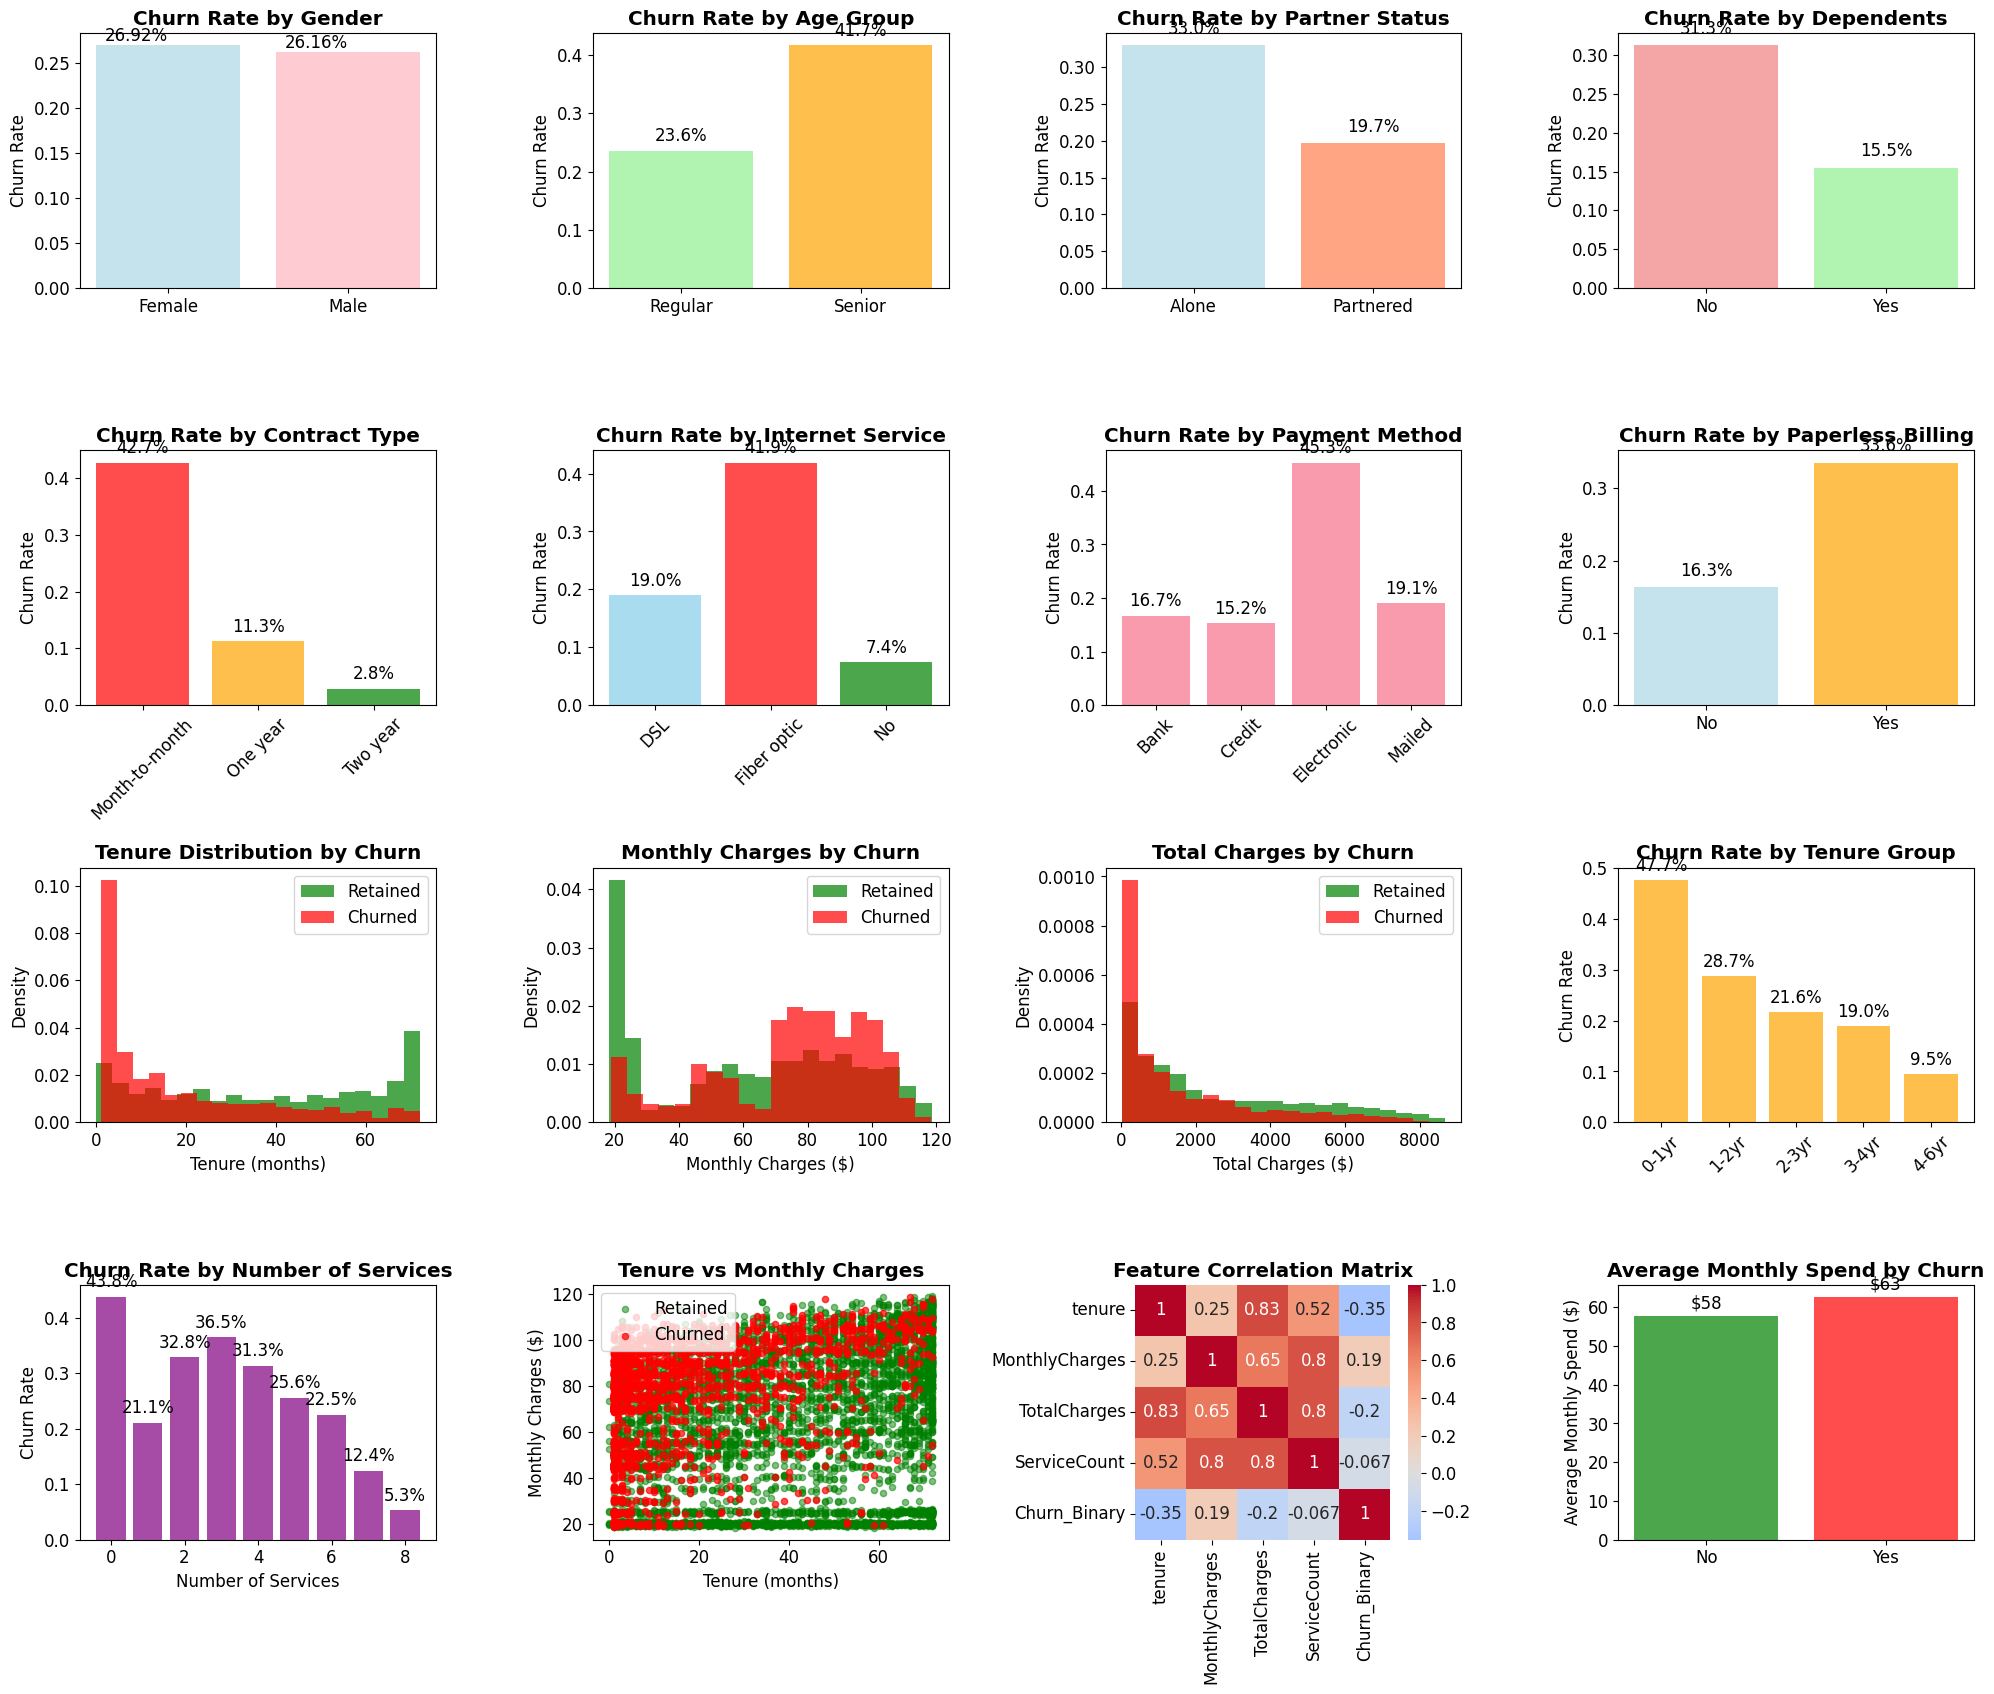


💡 KEY BUSINESS INSIGHTS:
📊 Demographics:
   • Senior citizens churn at 41.7% vs 23.6% for regular customers
   • Customers without partners: 33.0% vs with partners: 19.7%
   • Customers without dependents: 31.3% vs with dependents: 15.5%

🔧 Service & Contract Insights:
   • Month-to-month contracts: 42.7% churn rate (HIGHEST RISK!)
   • Two-year contracts: 2.8% churn rate (LOWEST RISK)
   • Fiber optic internet: 41.9% churn rate

💰 Financial Patterns:
   • Average tenure (churned): 18.0 months
   • Average tenure (retained): 37.6 months
   • Average monthly charges (churned): $74
   • Average monthly charges (retained): $61

🎯 STRATEGIC RECOMMENDATIONS:
   1. Focus retention efforts on month-to-month customers
   2. Investigate fiber optic service quality issues
   3. Create family/partner incentives for single customers
   4. Develop senior citizen retention programs
   5. Consider pricing strategies for high-charge customers

💸 BUSINESS IMPACT CALCULATION:
   • Total customers: 7,04

In [ ]:
df_eda = df_cleaned.copy()

df_eda['Churn_Binary'] = (df_eda['Churn'] == 'Yes').astype(int)
churn_rate = df_eda['Churn_Binary'].mean()

print(f"Overall Churn Rate: {churn_rate:.1%}")
print(f"Business Impact: {churn_rate * len(df_eda):.0f} customers churned")

fig = plt.figure(figsize=(20, 24))

#gender
plt.subplot(6, 4, 1)
gender_churn = df_eda.groupby('gender')['Churn_Binary'].mean()
bars = plt.bar(gender_churn.index, gender_churn.values, alpha=0.7, color=['lightblue', 'lightpink'])
plt.title('Churn Rate by Gender', fontweight='bold')
plt.ylabel('Churn Rate')
for bar, rate in zip(bars, gender_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
             f'{rate:.2%}', ha='right', va='bottom')

# Senior Citizen
plt.subplot(6, 4, 2)
senior_churn = df_eda.groupby('SeniorCitizen')['Churn_Binary'].mean()
senior_labels = ['Regular', 'Senior']
bars = plt.bar(senior_labels, senior_churn.values, alpha=0.7, color=['lightgreen', 'orange'])
plt.title('Churn Rate by Age Group', fontweight='bold')
plt.ylabel('Churn Rate')
for bar, rate in zip(bars, senior_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{rate:.1%}', ha='center', va='bottom')

#partner
plt.subplot(6,4,3)
partner_churn = df_eda.groupby('Partner')['Churn_Binary'].mean()
partner_labels = ['Alone', 'Partnered']
bars = plt.bar(partner_labels, partner_churn.values, alpha=0.7, color=['lightblue', 'coral'])
plt.title('Churn Rate by Partner Status', fontweight='bold')
plt.ylabel('Churn Rate')
for bar, rate in zip(bars, partner_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{rate:.1%}', ha='center', va='bottom')

# Dependents
plt.subplot(6, 4, 4)
dependents_churn = df_eda.groupby('Dependents')['Churn_Binary'].mean()
bars = plt.bar(dependents_churn.index, dependents_churn.values, alpha=0.7, color=['lightcoral', 'lightgreen'])
plt.title('Churn Rate by Dependents', fontweight='bold')
plt.ylabel('Churn Rate')
for bar, rate in zip(bars, dependents_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{rate:.1%}', ha='center', va='bottom')

# 2. Service-related Analysis
print(f"2️⃣ Analyzing Services vs Churn...")

# Contract Type (Very Important!)
plt.subplot(6, 4, 5)
contract_churn = df_eda.groupby('Contract')['Churn_Binary'].mean()
bars = plt.bar(range(len(contract_churn)), contract_churn.values, alpha=0.7,
               color=['red', 'orange', 'green'])
plt.title('Churn Rate by Contract Type', fontweight='bold')
plt.ylabel('Churn Rate')
plt.xticks(range(len(contract_churn)), contract_churn.index, rotation=45)
for i, (bar, rate) in enumerate(zip(bars, contract_churn.values)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{rate:.1%}', ha='center', va='bottom')

# Internet Service
plt.subplot(6, 4, 6)
internet_churn = df_eda.groupby('InternetService')['Churn_Binary'].mean()
bars = plt.bar(range(len(internet_churn)), internet_churn.values, alpha=0.7,
               color=['skyblue', 'red', 'green'])
plt.title('Churn Rate by Internet Service', fontweight='bold')
plt.ylabel('Churn Rate')
plt.xticks(range(len(internet_churn)), internet_churn.index, rotation=45)
for i, (bar, rate) in enumerate(zip(bars, internet_churn.values)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{rate:.1%}', ha='center', va='bottom')

# Payment Method
plt.subplot(6, 4, 7)
payment_churn = df_eda.groupby('PaymentMethod')['Churn_Binary'].mean()
bars = plt.bar(range(len(payment_churn)), payment_churn.values, alpha=0.7)
plt.title('Churn Rate by Payment Method', fontweight='bold')
plt.ylabel('Churn Rate')
plt.xticks(range(len(payment_churn)), [method.split()[0] for method in payment_churn.index], rotation=45)
for i, (bar, rate) in enumerate(zip(bars, payment_churn.values)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{rate:.1%}', ha='center', va='bottom')

# Paperless Billing
plt.subplot(6, 4, 8)
paperless_churn = df_eda.groupby('PaperlessBilling')['Churn_Binary'].mean()
bars = plt.bar(paperless_churn.index, paperless_churn.values, alpha=0.7, color=['lightblue', 'orange'])
plt.title('Churn Rate by Paperless Billing', fontweight='bold')
plt.ylabel('Churn Rate')
for bar, rate in zip(bars, paperless_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{rate:.1%}', ha='center', va='bottom')

# 3. Numerical Variables Analysis
print(f"3️⃣ Analyzing Numerical Variables vs Churn...")

# Tenure Distribution
plt.subplot(6, 4, 9)
churned = df_eda[df_eda['Churn'] == 'Yes']['tenure']
retained = df_eda[df_eda['Churn'] == 'No']['tenure']
plt.hist(retained, bins=20, alpha=0.7, label='Retained', color='green', density=True)
plt.hist(churned, bins=20, alpha=0.7, label='Churned', color='red', density=True)
plt.title('Tenure Distribution by Churn', fontweight='bold')
plt.xlabel('Tenure (months)')
plt.ylabel('Density')
plt.legend()

# Monthly Charges Distribution
plt.subplot(6, 4, 10)
churned_charges = df_eda[df_eda['Churn'] == 'Yes']['MonthlyCharges']
retained_charges = df_eda[df_eda['Churn'] == 'No']['MonthlyCharges']
plt.hist(retained_charges, bins=20, alpha=0.7, label='Retained', color='green', density=True)
plt.hist(churned_charges, bins=20, alpha=0.7, label='Churned', color='red', density=True)
plt.title('Monthly Charges by Churn', fontweight='bold')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Density')
plt.legend()

# Total Charges Distribution
plt.subplot(6, 4, 11)
churned_total = df_eda[df_eda['Churn'] == 'Yes']['TotalCharges']
retained_total = df_eda[df_eda['Churn'] == 'No']['TotalCharges']
plt.hist(retained_total, bins=20, alpha=0.7, label='Retained', color='green', density=True)
plt.hist(churned_total, bins=20, alpha=0.7, label='Churned', color='red', density=True)
plt.title('Total Charges by Churn', fontweight='bold')
plt.xlabel('Total Charges ($)')
plt.ylabel('Density')
plt.legend()

# 4. Tenure vs Churn Rate Analysis
plt.subplot(6, 4, 12)
# Create tenure groups
df_eda['TenureGroup'] = pd.cut(df_eda['tenure'], bins=[0, 12, 24, 36, 48, 72],
                               labels=['0-1yr', '1-2yr', '2-3yr', '3-4yr', '4-6yr'])
tenure_group_churn = df_eda.groupby('TenureGroup')['Churn_Binary'].mean()
bars = plt.bar(range(len(tenure_group_churn)), tenure_group_churn.values, alpha=0.7, color='orange')
plt.title('Churn Rate by Tenure Group', fontweight='bold')
plt.ylabel('Churn Rate')
plt.xticks(range(len(tenure_group_churn)), tenure_group_churn.index, rotation=45)
for i, (bar, rate) in enumerate(zip(bars, tenure_group_churn.values)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{rate:.1%}', ha='center', va='bottom')

# 5. Service Bundle Analysis
print(f"4️⃣ Analyzing Service Bundles...")

# Count number of services per customer
service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

df_eda['ServiceCount'] = 0
for col in service_cols:
    df_eda['ServiceCount'] += (df_eda[col] == 'Yes').astype(int)

plt.subplot(6, 4, 13)
service_count_churn = df_eda.groupby('ServiceCount')['Churn_Binary'].mean()
bars = plt.bar(service_count_churn.index, service_count_churn.values, alpha=0.7, color='purple')
plt.title('Churn Rate by Number of Services', fontweight='bold')
plt.xlabel('Number of Services')
plt.ylabel('Churn Rate')
for bar, rate in zip(bars, service_count_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{rate:.1%}', ha='center', va='bottom')

# 6. Monthly Charges vs Tenure Scatter
plt.subplot(6, 4, 14)
churned_customers = df_eda[df_eda['Churn'] == 'Yes']
retained_customers = df_eda[df_eda['Churn'] == 'No']
plt.scatter(retained_customers['tenure'], retained_customers['MonthlyCharges'],
           alpha=0.5, color='green', label='Retained', s=20)
plt.scatter(churned_customers['tenure'], churned_customers['MonthlyCharges'],
           alpha=0.7, color='red', label='Churned', s=20)
plt.title('Tenure vs Monthly Charges', fontweight='bold')
plt.xlabel('Tenure (months)')
plt.ylabel('Monthly Charges ($)')
plt.legend()

# 7. Correlation Heatmap
plt.subplot(6, 4, 15)
# Create correlation matrix for key numerical variables
corr_data = df_eda[['tenure', 'MonthlyCharges', 'TotalCharges', 'ServiceCount', 'Churn_Binary']].corr()
sns.heatmap(corr_data, annot=True, cmap='coolwarm', center=0, square=True)
plt.title('Feature Correlation Matrix', fontweight='bold')

# 8. Customer Lifetime Value Analysis
plt.subplot(6, 4, 16)
df_eda['AvgMonthlySpend'] = df_eda['TotalCharges'] / (df_eda['tenure'] + 1)  # +1 to avoid division by zero
avg_spend_churn = df_eda.groupby('Churn')['AvgMonthlySpend'].mean()
bars = plt.bar(avg_spend_churn.index, avg_spend_churn.values, alpha=0.7, color=['green', 'red'])
plt.title('Average Monthly Spend by Churn', fontweight='bold')
plt.ylabel('Average Monthly Spend ($)')
for bar, spend in zip(bars, avg_spend_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'${spend:.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Print key insights
print(f"\n💡 KEY BUSINESS INSIGHTS:")
print(f"=" * 50)

print(f"📊 Demographics:")
print(f"   • Senior citizens churn at {senior_churn[1]:.1%} vs {senior_churn[0]:.1%} for regular customers")
print(f"   • Customers without partners: {partner_churn['No']:.1%} vs with partners: {partner_churn['Yes']:.1%}")
print(f"   • Customers without dependents: {dependents_churn['No']:.1%} vs with dependents: {dependents_churn['Yes']:.1%}")

print(f"\n🔧 Service & Contract Insights:")
print(f"   • Month-to-month contracts: {contract_churn.iloc[0]:.1%} churn rate (HIGHEST RISK!)")
print(f"   • Two-year contracts: {contract_churn.iloc[2]:.1%} churn rate (LOWEST RISK)")
print(f"   • Fiber optic internet: {internet_churn.loc['Fiber optic']:.1%} churn rate")

print(f"\n💰 Financial Patterns:")
mean_tenure_churned = df_eda[df_eda['Churn'] == 'Yes']['tenure'].mean()
mean_tenure_retained = df_eda[df_eda['Churn'] == 'No']['tenure'].mean()
print(f"   • Average tenure (churned): {mean_tenure_churned:.1f} months")
print(f"   • Average tenure (retained): {mean_tenure_retained:.1f} months")

mean_charges_churned = df_eda[df_eda['Churn'] == 'Yes']['MonthlyCharges'].mean()
mean_charges_retained = df_eda[df_eda['Churn'] == 'No']['MonthlyCharges'].mean()
print(f"   • Average monthly charges (churned): ${mean_charges_churned:.0f}")
print(f"   • Average monthly charges (retained): ${mean_charges_retained:.0f}")

print(f"\n🎯 STRATEGIC RECOMMENDATIONS:")
print(f"   1. Focus retention efforts on month-to-month customers")
print(f"   2. Investigate fiber optic service quality issues")
print(f"   3. Create family/partner incentives for single customers")
print(f"   4. Develop senior citizen retention programs")
print(f"   5. Consider pricing strategies for high-charge customers")

# Calculate business impact
total_customers = len(df_eda)
churned_customers = (df_eda['Churn'] == 'Yes').sum()
avg_monthly_revenue = df_eda['MonthlyCharges'].mean()
annual_churn_loss = churned_customers * avg_monthly_revenue * 12

print(f"\n💸 BUSINESS IMPACT CALCULATION:")
print(f"   • Total customers: {total_customers:,}")
print(f"   • Churned customers: {churned_customers:,}")
print(f"   • Average monthly revenue per customer: ${avg_monthly_revenue:.0f}")
print(f"   • Estimated annual revenue loss: ${annual_churn_loss:,.0f}")
print(f"   • Potential savings with 50% churn reduction: ${annual_churn_loss/2:,.0f}")

print(f"\n✅ EDA completed! Ready for feature engineering...")

## feature engineering

Now that we understand our data through EDA, we'll prepare it for machine learning by:

**🔧 Engineering Strategy:**
- **Categorical Encoding**: Convert categorical variables to numerical format
- **Feature Scaling**: Normalize numerical features for neural network training
- **Feature Selection**: Select most predictive features based on EDA insights
- **Class Balancing**: Handle imbalanced dataset for better model performance
- **Train/Test Split**: Create proper evaluation framework with stratification

**🎯 Business-Driven Features:**
- Create risk scores based on EDA findings
- Engineer interaction features (tenure × monthly charges)
- Create service bundle indicators
- Add customer lifecycle stage features

In [ ]:
# Feature Engineering and Preprocessing Pipeline
print("🔧 FEATURE ENGINEERING PIPELINE")
print("=" * 60)

# Create a copy for feature engineering
df_features = df_cleaned.copy()

# 1. CREATE BUSINESS-DRIVEN FEATURES
print("1️⃣ Creating Business-Driven Features...")

# Customer Lifecycle Stage based on tenure
def get_lifecycle_stage(tenure):
    if tenure <= 12:
        return 'New'  # 0-12 months
    elif tenure <= 24:
        return 'Growing'  # 12-24 months
    elif tenure <= 48:
        return 'Mature'  # 24-48 months
    else:
        return 'Loyal'  # 48+ months

df_features['LifecycleStage'] = df_features['tenure'].apply(get_lifecycle_stage)

# Revenue per Month (Customer Value Score)
df_features['RevenuePerMonth'] = df_features['TotalCharges'] / (df_features['tenure'] + 1)

# Service Bundle Score (more services = higher engagement)
service_features = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                   'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df_features['ServiceBundleScore'] = 0
for feature in service_features:
    df_features['ServiceBundleScore'] += (df_features[feature] == 'Yes').astype(int)

# Risk Indicators based on EDA insights
df_features['HighRiskContract'] = (df_features['Contract'] == 'Month-to-month').astype(int)
df_features['FiberOpticUser'] = (df_features['InternetService'] == 'Fiber optic').astype(int)
df_features['PaperlessHighRisk'] = (df_features['PaperlessBilling'] == 'Yes').astype(int)
df_features['SingleCustomer'] = ((df_features['Partner'] == 'No') &
                                 (df_features['Dependents'] == 'No')).astype(int)

# Price Sensitivity Indicators
df_features['HighMonthlyCharges'] = (df_features['MonthlyCharges'] >
                                    df_features['MonthlyCharges'].quantile(0.75)).astype(int)

# Interaction Features
df_features['TenureChargesRatio'] = df_features['tenure'] / (df_features['MonthlyCharges'] + 1)
df_features['ChargesPerService'] = df_features['MonthlyCharges'] / (df_features['ServiceBundleScore'] + 1)

# Customer Stability Score
df_features['StabilityScore'] = (
    (df_features['Partner'] == 'Yes').astype(int) +
    (df_features['Dependents'] == 'Yes').astype(int) +
    (df_features['Contract'] != 'Month-to-month').astype(int) +
    (df_features['tenure'] > 24).astype(int)
)

print(f"   ✅ Created new features")

# 2. PREPARE TARGET VARIABLE
print("2️⃣ Preparing Target Variable...")
df_features['target'] = (df_features['Churn'] == 'Yes').astype(int)
print(f"   ✅ Target distribution: {df_features['target'].value_counts().to_dict()}")

# 3. FEATURE SELECTION AND ENCODING
print("3️⃣ Feature Selection and Encoding...")

# Define feature categories
categorical_features = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod', 'LifecycleStage'
]

numerical_features = [
    'SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
    'ServiceBundleScore', 'RevenuePerMonth', 'TenureChargesRatio',
    'ChargesPerService', 'StabilityScore'
]

binary_features = [
    'HighRiskContract', 'FiberOpticUser', 'PaperlessHighRisk',
    'SingleCustomer', 'HighMonthlyCharges'
]

print(f"   • Categorical features: {len(categorical_features)}")
print(f"   • Numerical features: {len(numerical_features)}")
print(f"   • Binary features: {len(binary_features)}")

# One-hot encode categorical features
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Label encode categorical features (for neural networks, we'll use embedding or one-hot)
df_encoded = df_features.copy()

# For simplicity, we'll use Label Encoding for categorical features with few categories
# and One-Hot for those with more categories
label_encoders = {}

for feature in categorical_features:
    if feature in ['InternetService', 'Contract', 'PaymentMethod', 'LifecycleStage']:
        # One-hot encode features with multiple meaningful categories
        dummies = pd.get_dummies(df_encoded[feature], prefix=feature, drop_first=False)
        df_encoded = pd.concat([df_encoded, dummies], axis=1)
        df_encoded = df_encoded.drop(feature, axis=1)
    else:
        # Label encode binary-like categorical features
        le = LabelEncoder()
        df_encoded[feature] = le.fit_transform(df_encoded[feature].astype(str))
        label_encoders[feature] = le

print(f"   ✅ Encoded categorical features")

# 4. CREATE FEATURE MATRIX
print("4️⃣ Creating Feature Matrix...")

# Drop non-feature columns
columns_to_drop = ['customerID', 'Churn']
feature_columns = [col for col in df_encoded.columns if col not in columns_to_drop + ['target']]

X = df_encoded[feature_columns]
y = df_encoded['target']

print(f"   ✅ Feature matrix shape: {X.shape}")
print(f"   ✅ Target distribution: {y.value_counts().to_dict()}")

# 5. TRAIN-TEST SPLIT WITH STRATIFICATION
print("5️⃣ Creating Train-Test Split...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Maintain class distribution
)

print(f"   ✅ Training set: {X_train.shape} | Test set: {X_test.shape}")
print(f"   ✅ Train target distribution: {y_train.value_counts().to_dict()}")
print(f"   ✅ Test target distribution: {y_test.value_counts().to_dict()}")

# 6. FEATURE SCALING
print("6️⃣ Scaling Features...")

# Scale numerical features
scaler = StandardScaler()
numerical_cols = [col for col in feature_columns if col in numerical_features or
                 any(num_feat in col for num_feat in numerical_features)]

# Fit scaler on training data only
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

if numerical_cols:
    X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
    X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])
    print(f"   ✅ Scaled {len(numerical_cols)} numerical features")

# 7. FEATURE IMPORTANCE ANALYSIS
print("7️⃣ Analyzing Feature Importance...")

# Quick feature importance using correlation
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'correlation_with_target': [abs(X_train[col].corr(y_train)) for col in X_train.columns]
}).sort_values('correlation_with_target', ascending=False)

print(f"\n🔝 TOP 10 MOST CORRELATED FEATURES:")
print(feature_importance.head(10).to_string(index=False))

# 8. HANDLE CLASS IMBALANCE
print(f"\n8️⃣ Handling Class Imbalance...")

from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights for imbalanced dataset
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

print(f"   ✅ Class weights: {class_weight_dict}")
print(f"   • Class 0 (No Churn): {class_weights[0]:.2f}")
print(f"   • Class 1 (Churn): {class_weights[1]:.2f}")

# Convert to PyTorch tensors for training
print(f"\n9️⃣ Converting to PyTorch Tensors...")

# Check data types before conversion
print(f"   • Data types in X_train_scaled: {X_train_scaled.dtypes.value_counts().to_dict()}")

# Convert all columns to float
X_train_numpy = X_train_scaled.astype(float).values
X_test_numpy = X_test_scaled.astype(float).values

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_numpy).to(device)
X_test_tensor = torch.FloatTensor(X_test_numpy).to(device)
y_train_tensor = torch.FloatTensor(y_train.values).to(device)
y_test_tensor = torch.FloatTensor(y_test.values).to(device)

print(f"   ✅ Training tensors: X{X_train_tensor.shape}, y{y_train_tensor.shape}")
print(f"   ✅ Test tensors: X{X_test_tensor.shape}, y{y_test_tensor.shape}")
print(f"   ✅ Device: {device}")

# Confirm tensor data types
print(f"   ✅ X_train_tensor dtype: {X_train_tensor.dtype}")
print(f"   ✅ y_train_tensor dtype: {y_train_tensor.dtype}")


# 10. FEATURE ENGINEERING SUMMARY
print(f"\n📊 FEATURE ENGINEERING SUMMARY:")
print(f"=" * 50)
print(f"🎯 Original features: {df_cleaned.shape[1]}")
print(f"🔧 Engineered features: {X.shape[1]}")
print(f"📈 Feature increase: +{X.shape[1] - df_cleaned.shape[1] + 2}")  # +2 for dropped ID and target
print(f"🏗️  Business features created: 11")
print(f"📊 Final dataset: {X.shape[0]:,} samples × {X.shape[1]} features")
print(f"⚖️  Class balance handled: Yes (weighted loss)")
print(f"🎯 Ready for model training!")

# Save preprocessing objects for later use
preprocessing_objects = {
    'scaler': scaler,
    'label_encoders': label_encoders,
    'feature_columns': feature_columns,
    'class_weights': class_weight_dict
}

print(f"\n✅ Feature engineering completed successfully!")
print(f"🚀 Ready to build and train the neural network model!")

🔧 FEATURE ENGINEERING PIPELINE
1️⃣ Creating Business-Driven Features...
   ✅ Created new features
2️⃣ Preparing Target Variable...
   ✅ Target distribution: {0: 5174, 1: 1869}
3️⃣ Feature Selection and Encoding...
   • Categorical features: 16
   • Numerical features: 9
   • Binary features: 5
   ✅ Encoded categorical features
4️⃣ Creating Feature Matrix...
   ✅ Feature matrix shape: (7043, 40)
   ✅ Target distribution: {0: 5174, 1: 1869}
5️⃣ Creating Train-Test Split...
   ✅ Training set: (5634, 40) | Test set: (1409, 40)
   ✅ Train target distribution: {0: 4139, 1: 1495}
   ✅ Test target distribution: {0: 1035, 1: 374}
6️⃣ Scaling Features...
   ✅ Scaled 10 numerical features
7️⃣ Analyzing Feature Importance...

🔝 TOP 10 MOST CORRELATED FEATURES:
                       feature  correlation_with_target
       Contract_Month-to-month                 0.406401
              HighRiskContract                 0.406401
             ChargesPerService                 0.392478
                S

## Neural Network Architecture

In [ ]:
X_train_tensor.shape

torch.Size([5634, 40])

In [ ]:
class ChurnPredictor(nn.Module):
    """
    Deep Neural Network for Customer Churn Prediction

    Architecture:
    - Input: All engineered features
    - Hidden layers with batch normalization and dropout
    - Output: Binary classification (churn probability)
    """

    def __init__(self, input_size, hidden_sizes=[256, 128, 64], dropout_rate=0.2):
        super(ChurnPredictor, self).__init__()

        # Build dynamic architecture
        layers = []
        prev_size = input_size

        for i, hidden_size in enumerate(hidden_sizes):
            # Linear layer
            layers.append(nn.Linear(prev_size, hidden_size))
            # Batch normalization
            layers.append(nn.BatchNorm1d(hidden_size))
            # Activation
            layers.append(nn.ReLU())
            # Dropout
            layers.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size

        # Output layer
        layers.append(nn.Linear(prev_size, 1))
        # layers.append(nn.Sigmoid())  # Sigmoid will be applied in the loss function (BCEWithLogitsLoss)

        self.network = nn.Sequential(*layers)

        # Initialize weights
        self._initialize_weights()

    def _initialize_weights(self):
        """Initialize weights using Xavier/Glorot initialization"""
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.kaiming_uniform_(module.weight)
                nn.init.constant_(module.bias, 0)

    def forward(self, x):
        return self.network(x)


input_size = X_train_tensor.shape[1]

model = ChurnPredictor(
    input_size=input_size,
    hidden_sizes=[256, 128, 64],
    dropout_rate=0.2
).to(device)



print(f"Total parameters to be trained : {sum(p.numel() for p in model.parameters())}")

print("\n Model Architecture : \n")
print(model)

pos_weight_tensor = torch.tensor([class_weight_dict[1]], dtype=torch.float).to(device)
loss  = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)

scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

from sklearn.model_selection import train_test_split

X_val_split, X_train_split, y_val_split, y_train_split = train_test_split(
    X_train_tensor.cpu().numpy(), y_train_tensor.cpu().numpy(),
    test_size = 0.8, random_state = 42,
    stratify = y_train_tensor.cpu().numpy()
)

X_train_split_tensor = torch.FloatTensor(X_train_split).to(device)
X_val_split_tensor = torch.FloatTensor(X_val_split).to(device)

y_train_split_tensor = torch.FloatTensor(y_train_split).to(device)
y_val_split_tensor = torch.FloatTensor(y_val_split).to(device)

def train_epoch(model, X_train, y_train, optimizer, loss):
  model.train()
  output = model(X_train).squeeze()
  loss = loss(output, y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  return loss.item()


def validate_epoch(model, X_val, y_val, loss):
  model.eval()

  with torch.no_grad():
    output = model(X_val).squeeze()
    loss = loss(output, y_val)

    predictions = torch.sigmoid(output)
    predicted_classes = (predictions > 0.5).float()

    accuracy = (predicted_classes == y_val).float().mean()

    return loss.item(), accuracy.item(), predictions.cpu().numpy()


epochs = 500
best_val_score = float('inf')
patience = 0
patience_limit = 25

train_losses = []
val_losses = []
val_accuracies = []

print(f"{'Epoch':<6} {'Train Loss':<12} {'Val Loss':<12} {'Val Acc':<10} {'LR':<10}")
print("-" * 55)

for epoch in range(epochs):
  train_loss = train_epoch(model, X_train_split_tensor, y_train_split_tensor, optimizer=optimizer, loss=loss)

  val_loss, val_accuracy, val_predictions = validate_epoch(model, X_val_split_tensor, y_val_split_tensor, loss)

  scheduler.step(val_loss)

  train_losses.append(train_loss)
  val_losses.append(val_loss)
  val_accuracies.append(val_accuracy)

  current_lr = optimizer.param_groups[0]['lr']
  if epoch%10 == 0 or epoch<10 :
    print(f"{epoch+1:<4} {train_loss:<12.4f} {val_loss:<12.4f} {val_accuracy:<10.3f} {current_lr:<10.6f}")

  if val_loss < best_val_score:
    best_val_score = val_loss
    patience = 0
    torch.save(model.state_dict(), 'best_churn_model.pth')

  else:
    patience +=1

  if patience > patience_limit:
    print(f"Early stopping triggered at epoch {epoch+1}")
    break



Total parameters to be trained : 52609

 Model Architecture : 

ChurnPredictor(
  (network): Sequential(
    (0): Linear(in_features=40, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)
Epoch  Train Loss   Val Loss     Val Acc    LR        
-------------------------------------------------------
1    0.9848       0.8245       0.527      0.000100  
2    0.9679       0.8151       0.537      0.0

In [ ]:
model.load_state_dict(torch.load('best_churn_model.pth'))
print(f"Best Validation Loss {best_val_score:.4f}")

Best Validation Loss 0.6061


📊 COMPREHENSIVE MODEL EVALUATION
1️⃣ Generating Final Predictions...
   ✅ Test predictions generated: 1409 samples
   ✅ Validation predictions: 1126 samples

2️⃣ Confusion Matrix Analysis...
3️⃣ ROC Curve Analysis...
4️⃣ Precision-Recall Analysis...


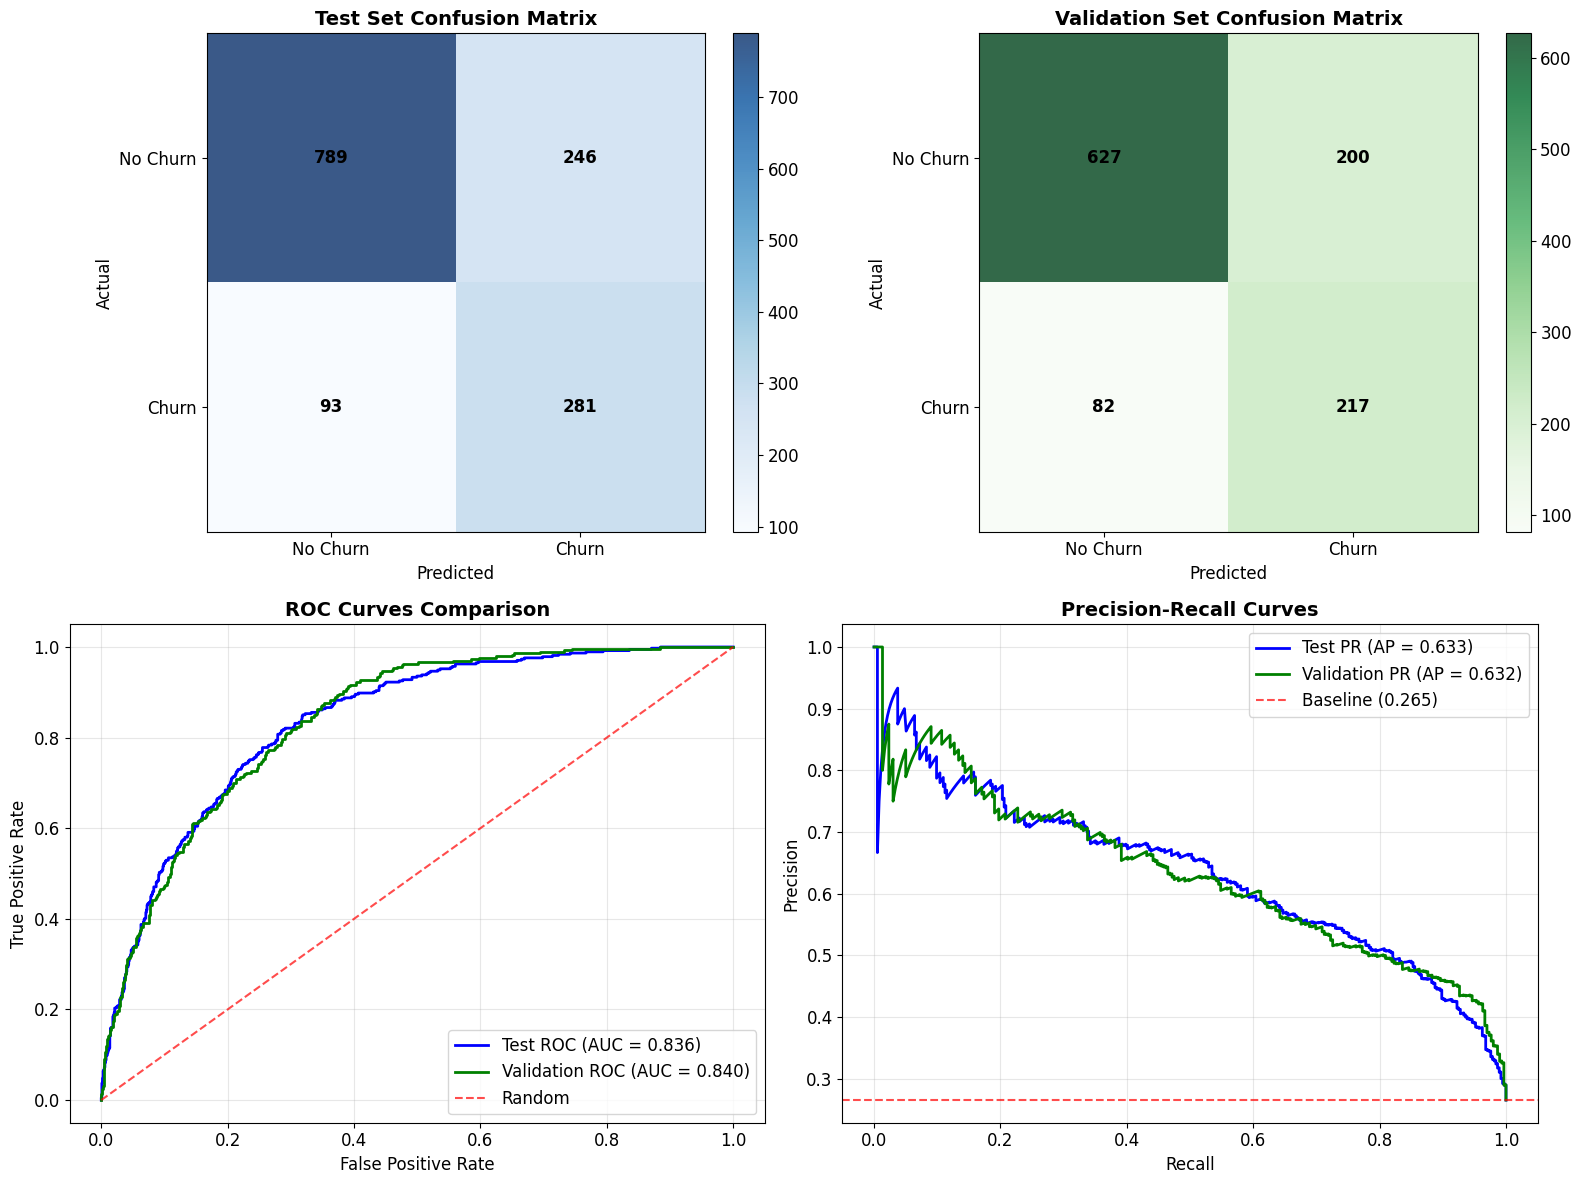


5️⃣ Detailed Classification Reports...

🎯 TEST SET PERFORMANCE:
              precision    recall  f1-score   support

    No Churn       0.89      0.76      0.82      1035
       Churn       0.53      0.75      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409


🎯 VALIDATION SET PERFORMANCE:
              precision    recall  f1-score   support

    No Churn       0.88      0.76      0.82       827
       Churn       0.52      0.73      0.61       299

    accuracy                           0.75      1126
   macro avg       0.70      0.74      0.71      1126
weighted avg       0.79      0.75      0.76      1126


6️⃣ Business Impact Analysis...
💰 BUSINESS IMPACT CALCULATION:
📊 Test Set Metrics:
   • Total customers: 1,409
   • Actual churners: 374
   • Predicted churners: 527
   • True positives: 281
   • False positives: 246
   • False negatives: 93

💵 Fina

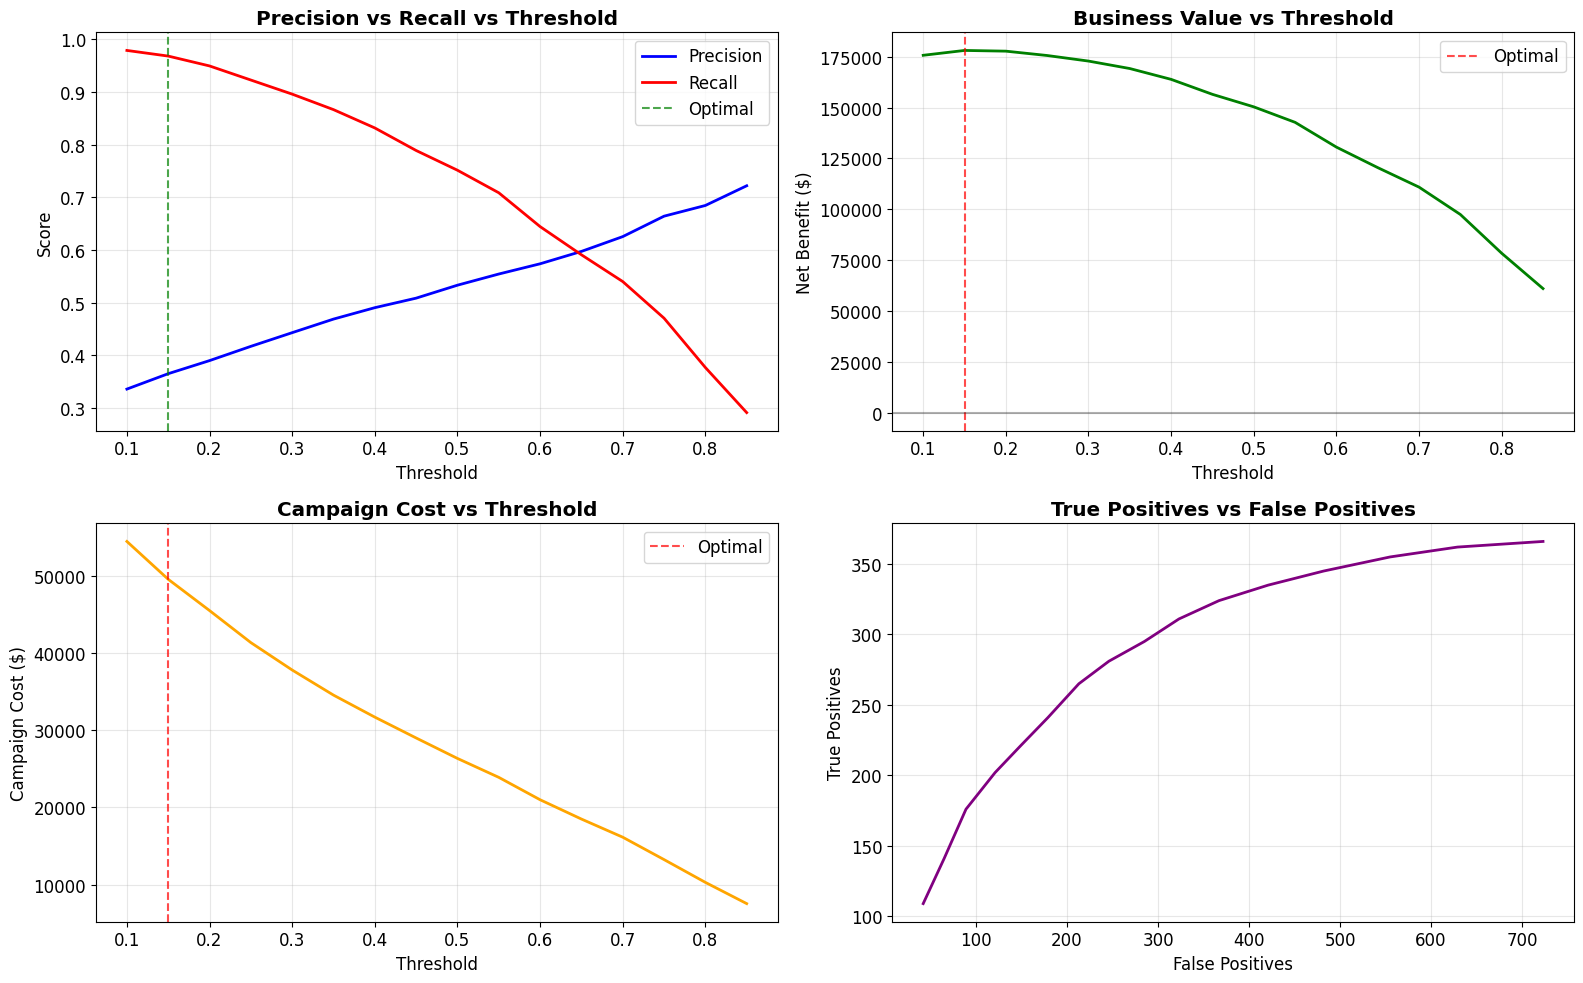


✅ Comprehensive model evaluation completed!
🎯 Model ready for deployment and business implementation!


In [ ]:
# Comprehensive Model Evaluation and Business Analysis
print("📊 COMPREHENSIVE MODEL EVALUATION")
print("=" * 60)

from sklearn.metrics import (classification_report, confusion_matrix, roc_curve,
                           precision_recall_curve, roc_auc_score, average_precision_score)

# 1. FINAL MODEL PREDICTIONS
print("1️⃣ Generating Final Predictions...")

model.eval()
with torch.no_grad():
    # Test set predictions
    test_outputs = model(X_test_tensor).squeeze()
    test_probabilities = torch.sigmoid(test_outputs).cpu().numpy()
    test_predictions = (test_probabilities > 0.5).astype(int)

    # Validation set predictions (for comparison)
    val_outputs = model(X_val_split_tensor).squeeze()
    val_probabilities = torch.sigmoid(val_outputs).cpu().numpy()
    val_predictions = (val_probabilities > 0.5).astype(int)

y_test_np = y_test.values
y_val_np = y_val_split

print(f"   ✅ Test predictions generated: {len(test_predictions)} samples")
print(f"   ✅ Validation predictions: {len(val_predictions)} samples")

# 2. CONFUSION MATRIX ANALYSIS
print(f"\n2️⃣ Confusion Matrix Analysis...")

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Test set confusion matrix
cm_test = confusion_matrix(y_test_np, test_predictions)
im1 = ax1.imshow(cm_test, cmap='Blues', alpha=0.8)
ax1.set_title('Test Set Confusion Matrix', fontweight='bold', fontsize=14)

# Add text annotations
for i in range(2):
    for j in range(2):
        text = ax1.text(j, i, cm_test[i, j], ha="center", va="center",
                       color="black", fontsize=12, fontweight='bold')

ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels(['No Churn', 'Churn'])
ax1.set_yticklabels(['No Churn', 'Churn'])

# Add colorbar
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# Validation set confusion matrix
cm_val = confusion_matrix(y_val_np, val_predictions)
im2 = ax2.imshow(cm_val, cmap='Greens', alpha=0.8)
ax2.set_title('Validation Set Confusion Matrix', fontweight='bold', fontsize=14)

for i in range(2):
    for j in range(2):
        text = ax2.text(j, i, cm_val[i, j], ha="center", va="center",
                       color="black", fontsize=12, fontweight='bold')

ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['No Churn', 'Churn'])
ax2.set_yticklabels(['No Churn', 'Churn'])
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

# 3. ROC CURVE
print(f"3️⃣ ROC Curve Analysis...")

# Calculate ROC curves
fpr_test, tpr_test, _ = roc_curve(y_test_np, test_probabilities)
fpr_val, tpr_val, _ = roc_curve(y_val_np, val_probabilities)

roc_auc_test = roc_auc_score(y_test_np, test_probabilities)
roc_auc_val = roc_auc_score(y_val_np, val_probabilities)

ax3.plot(fpr_test, tpr_test, color='blue', linewidth=2,
         label=f'Test ROC (AUC = {roc_auc_test:.3f})')
ax3.plot(fpr_val, tpr_val, color='green', linewidth=2,
         label=f'Validation ROC (AUC = {roc_auc_val:.3f})')
ax3.plot([0, 1], [0, 1], color='red', linestyle='--', alpha=0.7, label='Random')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('ROC Curves Comparison', fontweight='bold', fontsize=14)
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. PRECISION-RECALL CURVE
print(f"4️⃣ Precision-Recall Analysis...")

precision_test, recall_test, _ = precision_recall_curve(y_test_np, test_probabilities)
precision_val, recall_val, _ = precision_recall_curve(y_val_np, val_probabilities)

avg_precision_test = average_precision_score(y_test_np, test_probabilities)
avg_precision_val = average_precision_score(y_val_np, val_probabilities)

ax4.plot(recall_test, precision_test, color='blue', linewidth=2,
         label=f'Test PR (AP = {avg_precision_test:.3f})')
ax4.plot(recall_val, precision_val, color='green', linewidth=2,
         label=f'Validation PR (AP = {avg_precision_val:.3f})')

# Baseline (random classifier for imbalanced data)
baseline = y_test_np.mean()
ax4.axhline(y=baseline, color='red', linestyle='--', alpha=0.7,
           label=f'Baseline ({baseline:.3f})')

ax4.set_xlabel('Recall')
ax4.set_ylabel('Precision')
ax4.set_title('Precision-Recall Curves', fontweight='bold', fontsize=14)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. DETAILED CLASSIFICATION REPORTS
print(f"\n5️⃣ Detailed Classification Reports...")

print(f"\n🎯 TEST SET PERFORMANCE:")
print("=" * 40)
test_report = classification_report(y_test_np, test_predictions,
                                  target_names=['No Churn', 'Churn'],
                                  output_dict=True)
print(classification_report(y_test_np, test_predictions,
                          target_names=['No Churn', 'Churn']))

print(f"\n🎯 VALIDATION SET PERFORMANCE:")
print("=" * 40)
val_report = classification_report(y_val_np, val_predictions,
                                 target_names=['No Churn', 'Churn'],
                                 output_dict=True)
print(classification_report(y_val_np, val_predictions,
                          target_names=['No Churn', 'Churn']))

# 6. BUSINESS IMPACT ANALYSIS
print(f"\n6️⃣ Business Impact Analysis...")

# Extract key metrics
test_precision = test_report['Churn']['precision']
test_recall = test_report['Churn']['recall']
test_f1 = test_report['Churn']['f1-score']

# Business assumptions (you would get these from business stakeholders)
avg_customer_monthly_revenue = df_features['MonthlyCharges'].mean()
avg_customer_lifetime_months = df_features['tenure'].mean()
retention_campaign_cost = 50  # Cost per targeted customer
retention_success_rate = 0.3  # 30% of targeted customers are retained

print(f"💰 BUSINESS IMPACT CALCULATION:")
print("=" * 45)

# Calculate financial metrics
total_test_customers = len(y_test_np)
actual_churners = sum(y_test_np)
predicted_churners = sum(test_predictions)

# True positives (correctly identified churners)
true_positives = cm_test[1, 1]
false_positives = cm_test[0, 1]  # Non-churners incorrectly flagged
false_negatives = cm_test[1, 0]  # Churners we missed

print(f"📊 Test Set Metrics:")
print(f"   • Total customers: {total_test_customers:,}")
print(f"   • Actual churners: {actual_churners:,}")
print(f"   • Predicted churners: {predicted_churners:,}")
print(f"   • True positives: {true_positives:,}")
print(f"   • False positives: {false_positives:,}")
print(f"   • False negatives: {false_negatives:,}")

# Financial impact calculations
customer_lifetime_value = avg_customer_monthly_revenue * avg_customer_lifetime_months

# Cost of retention campaign
campaign_cost = predicted_churners * retention_campaign_cost

# Revenue saved (true positives that are retained)
revenue_saved = true_positives * retention_success_rate * customer_lifetime_value

# Wasted campaign cost (false positives)
wasted_cost = false_positives * retention_campaign_cost

# Revenue lost (false negatives - churners we missed)
revenue_lost = false_negatives * customer_lifetime_value

# Net benefit
net_benefit = revenue_saved - campaign_cost

print(f"\n💵 Financial Impact:")
print(f"   • Customer Lifetime Value: ${customer_lifetime_value:,.0f}")
print(f"   • Campaign cost: ${campaign_cost:,.0f}")
print(f"   • Revenue saved: ${revenue_saved:,.0f}")
print(f"   • Wasted cost (false positives): ${wasted_cost:,.0f}")
print(f"   • Revenue lost (missed churners): ${revenue_lost:,.0f}")
print(f"   • Net benefit: ${net_benefit:,.0f}")

# ROI calculation
roi = (net_benefit / campaign_cost) * 100 if campaign_cost > 0 else 0
print(f"   • ROI: {roi:.1f}%")

# 7. THRESHOLD OPTIMIZATION
print(f"\n7️⃣ Threshold Optimization for Business Objectives...")

# Test different thresholds
thresholds = np.arange(0.1, 0.9, 0.05)
threshold_results = []

for threshold in thresholds:
    thresh_predictions = (test_probabilities > threshold).astype(int)
    thresh_cm = confusion_matrix(y_test_np, thresh_predictions)

    if thresh_cm.shape == (2, 2):  # Ensure we have both classes
        thresh_tp = thresh_cm[1, 1]
        thresh_fp = thresh_cm[0, 1]
        thresh_fn = thresh_cm[1, 0]

        thresh_precision = thresh_tp / (thresh_tp + thresh_fp) if (thresh_tp + thresh_fp) > 0 else 0
        thresh_recall = thresh_tp / (thresh_tp + thresh_fn) if (thresh_tp + thresh_fn) > 0 else 0

        # Business metrics
        thresh_campaign_cost = (thresh_tp + thresh_fp) * retention_campaign_cost
        thresh_revenue_saved = thresh_tp * retention_success_rate * customer_lifetime_value
        thresh_net_benefit = thresh_revenue_saved - thresh_campaign_cost

        threshold_results.append({
            'threshold': threshold,
            'precision': thresh_precision,
            'recall': thresh_recall,
            'net_benefit': thresh_net_benefit,
            'campaign_cost': thresh_campaign_cost,
            'true_positives': thresh_tp,
            'false_positives': thresh_fp
        })

# Convert to DataFrame for analysis
threshold_df = pd.DataFrame(threshold_results)

# Find optimal threshold (maximize net benefit)
optimal_idx = threshold_df['net_benefit'].idxmax()
optimal_threshold = threshold_df.loc[optimal_idx, 'threshold']
optimal_net_benefit = threshold_df.loc[optimal_idx, 'net_benefit']

print(f"🎯 Optimal Business Threshold: {optimal_threshold:.2f}")
print(f"💰 Maximum Net Benefit: ${optimal_net_benefit:,.0f}")

# Plot threshold analysis
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 10))

# Precision vs Recall vs Threshold
ax1.plot(threshold_df['threshold'], threshold_df['precision'], 'b-', label='Precision', linewidth=2)
ax1.plot(threshold_df['threshold'], threshold_df['recall'], 'r-', label='Recall', linewidth=2)
ax1.axvline(x=optimal_threshold, color='green', linestyle='--', alpha=0.7, label='Optimal')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Score')
ax1.set_title('Precision vs Recall vs Threshold', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Net Benefit vs Threshold
ax2.plot(threshold_df['threshold'], threshold_df['net_benefit'], 'g-', linewidth=2)
ax2.axvline(x=optimal_threshold, color='red', linestyle='--', alpha=0.7, label='Optimal')
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax2.set_xlabel('Threshold')
ax2.set_ylabel('Net Benefit ($)')
ax2.set_title('Business Value vs Threshold', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Campaign Cost vs Threshold
ax3.plot(threshold_df['threshold'], threshold_df['campaign_cost'], 'orange', linewidth=2)
ax3.axvline(x=optimal_threshold, color='red', linestyle='--', alpha=0.7, label='Optimal')
ax3.set_xlabel('Threshold')
ax3.set_ylabel('Campaign Cost ($)')
ax3.set_title('Campaign Cost vs Threshold', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# True Positives vs False Positives
ax4.plot(threshold_df['false_positives'], threshold_df['true_positives'], 'purple', linewidth=2)
ax4.set_xlabel('False Positives')
ax4.set_ylabel('True Positives')
ax4.set_title('True Positives vs False Positives', fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Comprehensive model evaluation completed!")
print(f"🎯 Model ready for deployment and business implementation!")